In [29]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [30]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [31]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

### Read Decision Forests Results

In [32]:
Ts_DF = [1,128,256, 512, 750, 1024, 1250, 1500, 2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/Permute_RF_oh_w_time0_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)

#PREWARDS = []
#PREGRETS = []
#for rep in range(10):
#    fn = f"../results/PAFM/DF/RF_optimal_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
#    data = np.load(fn)
#    states = data["future_states"]
#    prewards = []
#    pregrets = []
#    for k,T in enumerate(Ts_DF):
#        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#        preward = compute_normalized_future_rewards(irewards,100,0.5)
#        path, ireward_opt = path_opt(states[k,0], T, 100)
#        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#        prewards.append(np.sum(preward).item())
#        pregrets.append(pregret)
#    PREWARDS.append(prewards)
#    PREGRETS.append(pregrets)
#    PREWARDS_arr = np.vstack(PREWARDS)
#    PREGRETS_PAFM_DF_opt_arr = np.vstack(PREGRETS)
#print(PREGRETS_PAFM_DF_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 9)


In [52]:
Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]
step = 6
PREWARDS = []
PREGRETS = []
for rep in [1,6,7,8,9]:
    if rep == 1:
        fn = f"../results/PVFM/DF/RF_oh_w_time1000_160000_lookahead{step}_array6.npz"
        data = np.load(fn)
        PREGRETS.append(data["pregrest"])
    else:
        fn = f"../results/PVFM/DF/RF_oh_w_time1000_80000_lookahead{step}_reps{rep}.npz"
        data = np.load(fn)
        states = data["future_states"]
        prewards = []
        pregrets = []
        for k,T in enumerate(Ts_PVFM[:-1]):
            irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
            preward = compute_normalized_future_rewards(irewards,100,0.5)
            path, ireward_opt = path_opt(states[k,0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
        PREWARDS.append(prewards)
        PREGRETS.append(pregrets+[np.nan])
PREGRETS_PVFM_DF_lookahead_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_DF_lookahead_arr.shape)

(10, 7)


## PVAFM

In [48]:
# Load the single PVAFM file with all 10 reps
fn = f"../results/PVAFM/GBT_pregrets_gamma0.9_oh_w_time0_2048_lookahead{step}_10reps.npz"
data = np.load(fn)
pregrets_data = data["pregrets"]  # Shape: (10, 9)
t_list = data["t_list"][1:]  # Remove duplicate T=0, keep [0, 128, 256, 512, 750, 1024, 1250, 1500, 2048]

# Map PVAFM time points to match Ts_DF structure 
# Ts_DF = [1,128,256, 512, 750, 1024, 1250, 1500, 2048]
# t_list = [0,128,256, 512, 750, 1024, 1250, 1500, 2048] (after removing duplicate)

PREWARDS = []
PREGRETS = []
for rep in range(10):
    # Use all pregrets for this rep (all 9 values including T=0 equivalent)
    rep_pregrets = pregrets_data[rep, :]  # Keep all columns
    PREGRETS.append(rep_pregrets.tolist())
    # For PREWARDS, we can set to zeros or derive from pregrets if needed
    PREWARDS.append([0.0] * len(rep_pregrets))
    

PREWARDS_arr = np.vstack(PREWARDS)
PREGRETS_PVAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PVAFM_DF_arr.shape)
print("PVAFM time points:", t_list)

(10, 9)
PVAFM time points: [   0  128  256  512  750 1024 1250 1500 2048]


### Read Neural Net Results

In [49]:
Ts_NN = [1,128,256,512]+[750]+[1024,1250,1500,2048]

step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/NN/Permute_NN_onehot_w_lookahead_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_NN):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_NN_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_NN_arr.shape)

#PREWARDS = []
#PREGRETS = []
#for rep in range(1):
#    fn = f"../results/PAFM/NN/NN_oracle_w_lookahead_PAFM.npz"
#    data = np.load(fn)
#    states = data["future_states"]
#    prewards = []
#    pregrets = []
#    for k,T in enumerate(Ts_NN):
#        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#        preward = compute_normalized_future_rewards(irewards,100,0.5)
#        path, ireward_opt = path_opt(states[k,0], T, 100)
#        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#        prewards.append(np.sum(preward).item())
#        pregrets.append(pregret)
#    PREWARDS.append(prewards)
#    PREGRETS.append(pregrets)
#    PREWARDS_arr = np.vstack(PREWARDS)
#    PREGRETS_PAFM_NN_opt_arr = np.vstack(PREGRETS)
#print(PREGRETS_PAFM_NN_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 9)


# Read RL baseline

In [34]:
fn = f"../results/RL/pregret_fqi_notime.npz"
data = np.load(fn)
data['pregret_list']

array([1.02055431, 1.2008456 , 1.18411001, 1.18927797, 1.19613473,
       1.18778069, 1.1278969 , 1.18778069])

In [35]:
# Load offline FQI data
fn = f"../results/RL/offline_pregrets_fqi.npz"
data = np.load(fn)
PREGRETS_FQI_notime = data["pregret_list_notime"]
PREGRETS_FQI_time = data["pregret_list_time"]
Ts_RL_offline = data["t_list"]
print(f"Offline FQI data loaded: {PREGRETS_FQI_notime.shape} reps x time points")
print(f"Time points: {Ts_RL_offline}")
print(f"FQI notime data shape: {PREGRETS_FQI_notime.shape}")
print(f"FQI time data shape: {PREGRETS_FQI_time.shape}")

# Check if T=0 exists and handle it for log plotting
if Ts_RL_offline[0] == 0:
    print("Found T=0 in data - need to handle for log scale")
    # For log plotting, we'll need to either exclude T=0 or replace it with a small value
    Ts_RL_offline_log = Ts_RL_offline.copy()
    Ts_RL_offline_log[0] = 1  # Replace 0 with 1 for log plotting
    print(f"Modified time points for log scale: {Ts_RL_offline_log}")
else:
    Ts_RL_offline_log = Ts_RL_offline
    print("No T=0 found, using original time points")

# Load original FQI data for comparison
PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_fqi_notime.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_FQI_notime_orig = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_fqi_time.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_FQI_time_orig = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_harmonic_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_hmn_time = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_known_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_period = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_unknown_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_time = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_notime.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_notime = np.vstack(PREGRETS)

Offline FQI data loaded: (10, 8) reps x time points
Time points: [    0   128   512  1024  2048  4096 10000 20000]
FQI notime data shape: (10, 8)
FQI time data shape: (10, 8)
Found T=0 in data - need to handle for log scale
Modified time points for log scale: [    1   128   512  1024  2048  4096 10000 20000]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_48465/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


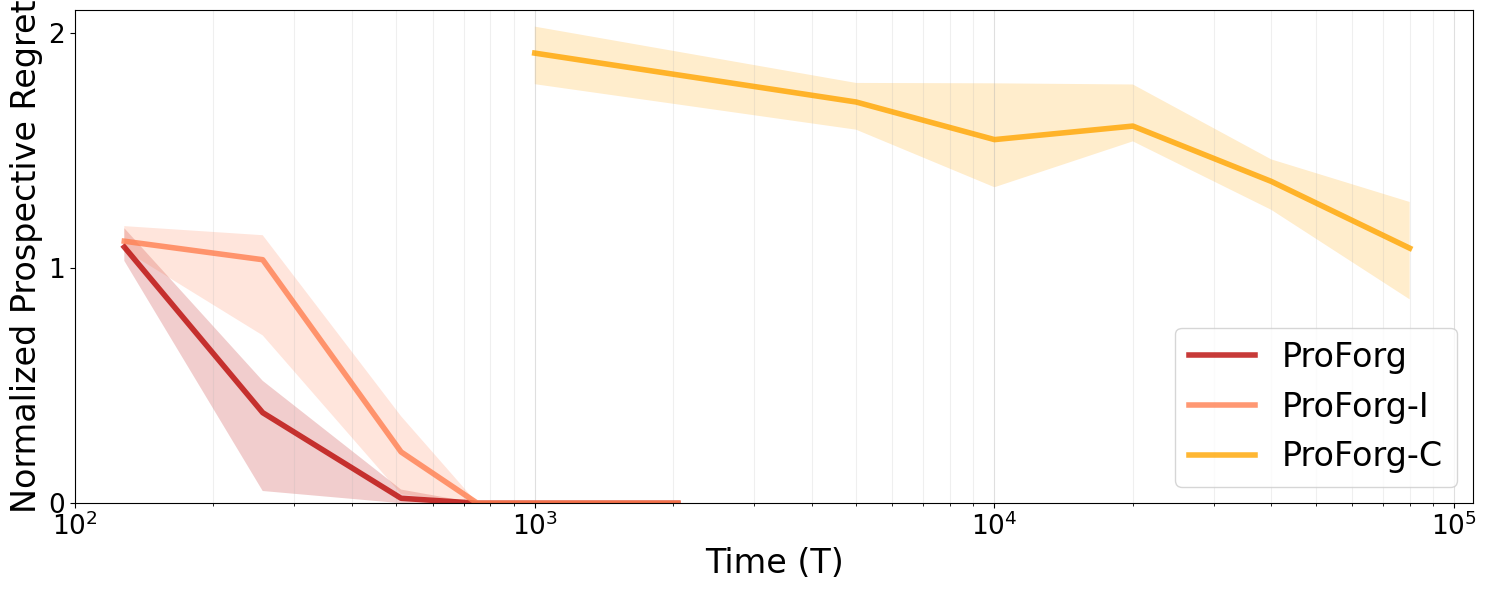

In [148]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 24

pafm_df, pvafm_df = get_close_colors("OrRd", start = 0.45, delta = 0.4, n = 2)
pafm_df, pafm_df_opt = get_close_colors("OrRd", start = 0.65, delta = 0.3, n = 2) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_oh_RF": pafm_df,
          "PAFM_opt_RF":pafm_df_opt,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI":rl_fqi,
          "RL_TQL":rl_tql,
          "PAFM": pafm_df,
          "PVAFM": pvafm_df
          }



median = np.median(PREGRETS_PVAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PVAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PVAFM_DF_arr, 75, axis=0)
plt.plot(Ts_DF[1:], median[1:],color=colors['PVAFM'], lw = linewidth,alpha = 0.8,label = 'ProForg')
plt.fill_between(Ts_DF[1:], q25[1:], q75[1:], color=colors['PVAFM'], alpha=0.20, edgecolor="none")

Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]



median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
plt.plot(Ts_DF[1:], median[1:],color='coral', lw = linewidth,alpha = 0.8,label = 'ProForg-I')
plt.fill_between(Ts_DF[1:], q25[1:], q75[1:], color='coral', alpha=0.20, edgecolor="none")

median = np.nanmedian(PREGRETS_PVFM_DF_lookahead_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PVFM_DF_lookahead_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PVFM_DF_lookahead_arr, 75, axis=0)
plt.plot(Ts_PVFM[:-1], median[:-1],color='orange', lw = linewidth,alpha = 0.8,label = 'ProForg-C')
plt.fill_between(Ts_PVFM[:-1], q25[:-1], q75[:-1], color='orange', alpha=0.20, edgecolor="none")

plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
plt.xscale('log')
# Use linear scale with standard tick marks
plt.grid(True, which = 'major', axis = 'x', linestyle = '-', alpha = 0.4)
plt.grid(True, which = 'minor', axis = 'x', linestyle = '-', alpha = 0.2)
plt.xticks(fontsize=fontsize-5)
plt.yticks([0,1,2],fontsize = fontsize-5)#plt.xscale('log')
#plt.title('Estimating Instantaneous Loss',fontsize = fontsize)
plt.legend(loc="lower right",fontsize = fontsize)
plt.tight_layout()
plt.ylim([0,2.1])
plt.xlim([100,110000])
plt.savefig('ProForg_IS.png')
